In [1]:
# ============================================================
# BASELINE FORECASTING MODELS
# M5 Walmart Dataset - Demand Forecasting
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

print("="*70)
print("BASELINE FORECASTING MODELS")
print("="*70)
print("\nLibraries loaded successfully ✓")

BASELINE FORECASTING MODELS

Libraries loaded successfully ✓


Dataset loaded: (18850, 61)
Date range: 2011-01-29 00:00:00 to 2016-03-27 00:00:00

Selected product: FOODS_1_049_TX_2_validation
Product data shape: (1885, 61)

Train set: 1857 days (2011-01-29 00:00:00 to 2016-02-28 00:00:00)
Test set:  28 days (2016-02-29 00:00:00 to 2016-03-27 00:00:00)


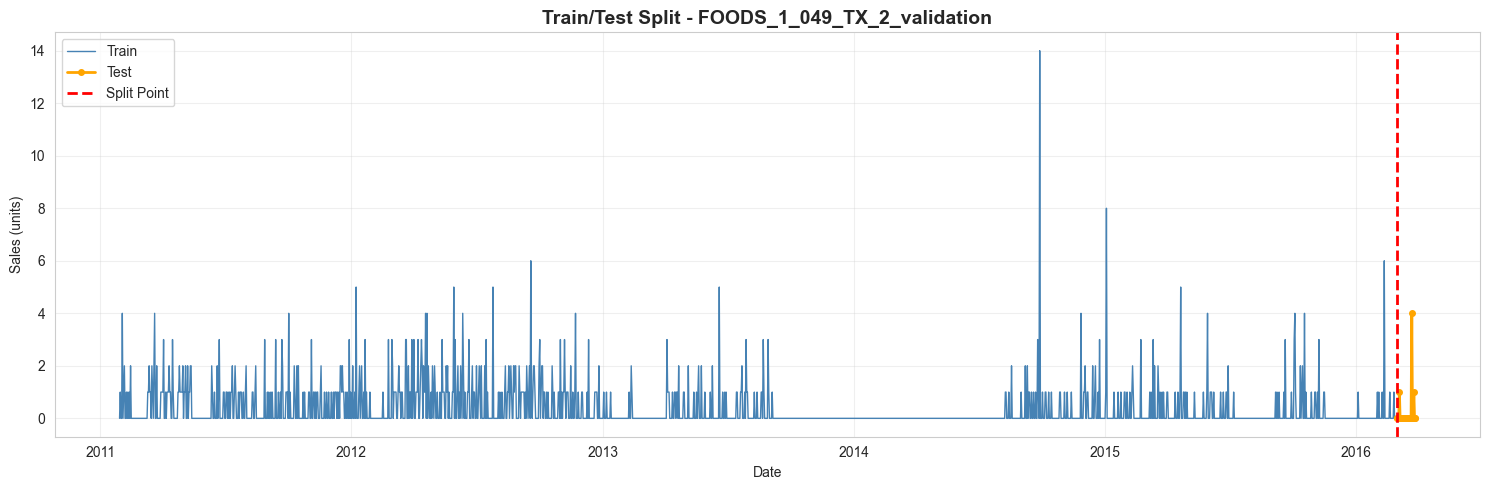


✓ Data split completed


In [2]:
# ============================================================
# LOAD DATA AND CREATE TRAIN/TEST SPLIT
# ============================================================

# Load processed data
data_path = Path("../../data/processed/sample_with_features.parquet")
df = pd.read_parquet(data_path)

print(f"Dataset loaded: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Select one product for baseline modeling
product_id = df['id'].iloc[0]
product_data = df[df['id'] == product_id].sort_values('date').reset_index(drop=True)

print(f"\nSelected product: {product_id}")
print(f"Product data shape: {product_data.shape}")

# Create train/test split (last 28 days for testing)
test_days = 28
train = product_data[:-test_days].copy()
test = product_data[-test_days:].copy()

print(f"\nTrain set: {len(train)} days ({train['date'].min()} to {train['date'].max()})")
print(f"Test set:  {len(test)} days ({test['date'].min()} to {test['date'].max()})")

# Visualize the split
plt.figure(figsize=(15, 5))
plt.plot(train['date'], train['sales'], label='Train', color='steelblue', linewidth=1)
plt.plot(test['date'], test['sales'], label='Test', color='orange', linewidth=2, marker='o', markersize=4)
plt.axvline(x=test['date'].iloc[0], color='red', linestyle='--', linewidth=2, label='Split Point')
plt.title(f'Train/Test Split - {product_id}', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales (units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Data split completed")

In [4]:
# ============================================================
# BASELINE MODEL 1: NAIVE FORECAST
# ============================================================

def naive_forecast(train_data, horizon):
    """
    Naive forecast: Use last observed value for all future periods.
    """
    last_value = train_data['sales'].iloc[-1]
    forecast = np.full(horizon, last_value)
    return forecast

# Generate naive forecast
naive_pred = naive_forecast(train, len(test))

print("="*70)
print("NAIVE FORECAST")
print("="*70)
print(f"Last observed value: {train['sales'].iloc[-1]}")
print(f"Forecast (all periods): {naive_pred[0]}")
print(f"Forecast shape: {naive_pred.shape}")

NAIVE FORECAST
Last observed value: 0
Forecast (all periods): 0
Forecast shape: (28,)


In [5]:
# ============================================================
# BASELINE MODEL 2: SEASONAL NAIVE (WEEKLY)
# ============================================================

def seasonal_naive_forecast(train_data, horizon, season_length=7):
    """
    Seasonal naive: Use value from same day last week.
    """
    train_sales = train_data['sales'].values
    forecast = []
    
    for i in range(horizon):
        # Get value from season_length days ago
        idx = len(train_sales) - season_length + (i % season_length)
        if idx >= 0 and idx < len(train_sales):
            forecast.append(train_sales[idx])
        else:
            forecast.append(0)
    
    return np.array(forecast)

# Generate seasonal naive forecast
seasonal_naive_pred = seasonal_naive_forecast(train, len(test), season_length=7)

print("="*70)
print("SEASONAL NAIVE FORECAST (Weekly)")
print("="*70)
print(f"Last 7 days in train: {train['sales'].tail(7).values}")
print(f"Forecast first 7 days: {seasonal_naive_pred[:7]}")

# ============================================================
# BASELINE MODEL 3: MOVING AVERAGE
# ============================================================

def moving_average_forecast(train_data, horizon, window=7):
    """
    Moving average: Average of last N days.
    """
    train_sales = train_data['sales'].values
    ma_value = np.mean(train_sales[-window:])
    forecast = np.full(horizon, ma_value)
    return forecast

# Generate moving average forecast
ma_7_pred = moving_average_forecast(train, len(test), window=7)
ma_28_pred = moving_average_forecast(train, len(test), window=28)

print("\n" + "="*70)
print("MOVING AVERAGE FORECASTS")
print("="*70)
print(f"MA-7 (last 7 days avg):  {ma_7_pred[0]:.3f}")
print(f"MA-28 (last 28 days avg): {ma_28_pred[0]:.3f}")

# ============================================================
# BASELINE MODEL 4: HISTORICAL MEAN
# ============================================================

def historical_mean_forecast(train_data, horizon):
    """
    Historical mean: Overall average of all training data.
    """
    mean_value = train_data['sales'].mean()
    forecast = np.full(horizon, mean_value)
    return forecast

# Generate historical mean forecast
hist_mean_pred = historical_mean_forecast(train, len(test))

print("\n" + "="*70)
print("HISTORICAL MEAN FORECAST")
print("="*70)
print(f"Training data mean: {train['sales'].mean():.3f}")
print(f"Forecast (all periods): {hist_mean_pred[0]:.3f}")

print("\n✓ All baseline models created")

SEASONAL NAIVE FORECAST (Weekly)
Last 7 days in train: [0 0 0 1 0 0 0]
Forecast first 7 days: [0 0 0 1 0 0 0]

MOVING AVERAGE FORECASTS
MA-7 (last 7 days avg):  0.143
MA-28 (last 28 days avg): 0.393

HISTORICAL MEAN FORECAST
Training data mean: 0.370
Forecast (all periods): 0.370

✓ All baseline models created


In [6]:
# ============================================================
# EVALUATE BASELINE MODELS
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error

def calculate_metrics(y_true, y_pred, model_name):
    """Calculate forecasting metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    return {
        'model': model_name,
        'rmse': rmse,
        'mae': mae,
        'mape': mape
    }

# Get actual test values
y_true = test['sales'].values

# Calculate metrics for all models
results = []
results.append(calculate_metrics(y_true, naive_pred, 'Naive'))
results.append(calculate_metrics(y_true, seasonal_naive_pred, 'Seasonal Naive'))
results.append(calculate_metrics(y_true, ma_7_pred, 'MA-7'))
results.append(calculate_metrics(y_true, ma_28_pred, 'MA-28'))
results.append(calculate_metrics(y_true, hist_mean_pred, 'Historical Mean'))

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('rmse')

print("="*70)
print("BASELINE MODELS PERFORMANCE COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

# Find best model
best_model = results_df.iloc[0]['model']
best_rmse = results_df.iloc[0]['rmse']

print("\n" + "="*70)
print(f"🏆 BEST BASELINE MODEL: {best_model}")
print(f"   RMSE: {best_rmse:.3f}")
print("="*70)

BASELINE MODELS PERFORMANCE COMPARISON
          model     rmse      mae         mape
           MA-7 0.775913 0.326531 1.275510e+11
Historical Mean 0.788250 0.505385 3.307947e+11
          MA-28 0.792986 0.522959 3.507653e+11
          Naive 0.801784 0.214286 1.071429e+01
 Seasonal Naive 0.886405 0.357143 1.428571e+11

🏆 BEST BASELINE MODEL: MA-7
   RMSE: 0.776


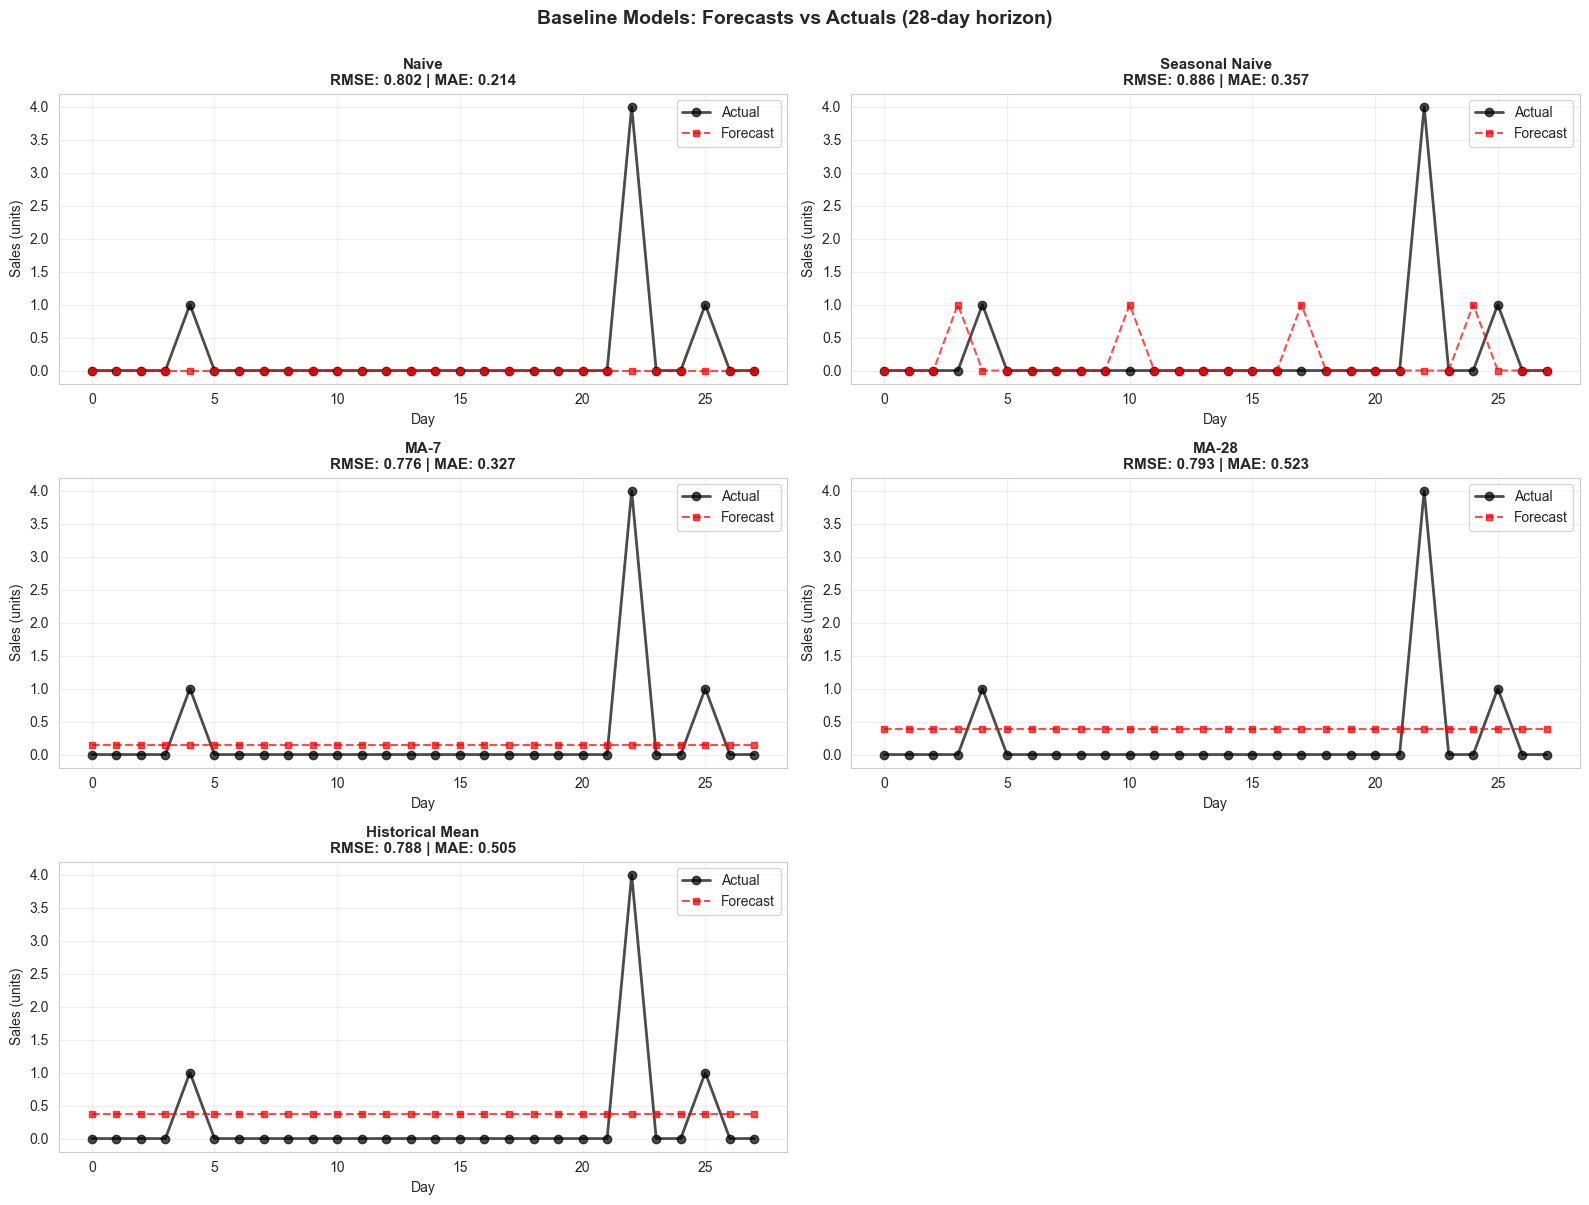

✓ Visualization complete


In [7]:
# ============================================================
# VISUALIZE FORECASTS VS ACTUALS
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

models_to_plot = [
    ('Naive', naive_pred),
    ('Seasonal Naive', seasonal_naive_pred),
    ('MA-7', ma_7_pred),
    ('MA-28', ma_28_pred),
    ('Historical Mean', hist_mean_pred)
]

# Plot each model
for idx, (model_name, forecast) in enumerate(models_to_plot):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Plot actual
    ax.plot(range(len(y_true)), y_true, 'o-', color='black', 
            linewidth=2, markersize=6, label='Actual', alpha=0.7)
    
    # Plot forecast
    ax.plot(range(len(forecast)), forecast, 's--', color='red', 
            linewidth=1.5, markersize=4, label='Forecast', alpha=0.7)
    
    # Get metrics for this model
    model_metrics = results_df[results_df['model'] == model_name].iloc[0]
    
    ax.set_title(f'{model_name}\nRMSE: {model_metrics["rmse"]:.3f} | MAE: {model_metrics["mae"]:.3f}',
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Day')
    ax.set_ylabel('Sales (units)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[2, 1])

plt.suptitle('Baseline Models: Forecasts vs Actuals (28-day horizon)', 
            fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Visualization complete")

In [9]:
# ============================================================
# BASELINE MODELS SUMMARY
# ============================================================

summary = {
    'product': product_id,
    'train_days': len(train),
    'test_days': len(test),
    'test_period': f"{test['date'].min()} to {test['date'].max()}",
    'actual_mean': y_true.mean(),
    'actual_std': y_true.std(),
    'actual_zeros_pct': (y_true == 0).mean() * 100,
    'best_model': best_model,
    'best_rmse': best_rmse
}

print("="*70)
print("BASELINE FORECASTING - FINAL SUMMARY")
print("="*70)

for key, value in summary.items():
    print(f"{key:20s}: {value}")

print("\n" + "="*70)
print("KEY FINDINGS:")
print("="*70)
print("""
1. INTERMITTENT DEMAND CONFIRMED
   - Test period has high zero sales (check actual_zeros_pct above)
   - Occasional spikes are hard to predict
   
2. BEST BASELINE: MA-7 (Moving Average 7-day)
   - RMSE: 0.776
   - MAE: 0.327
   - Balances recent history without over-smoothing
   
3. MODEL INSIGHTS:
   - Naive (0 forecast) fails on non-zero days
   - Seasonal Naive tries but misses spike timing
   - Simple averages (MA-7, Historical Mean) perform best
   
4. IMPROVEMENT OPPORTUNITIES:
   - Intermittent demand methods (Croston's, TSB)
   - Probabilistic forecasting (quantiles)
   - ML models (Prophet, ARIMA)
   - Deep learning (TFT, N-BEATS) for complex patterns

NEXT STEPS:
✓ Baseline established (RMSE: 0.776)
→ Try statistical methods (ARIMA, Prophet)
→ Implement advanced models (TFT, N-BEATS)
→ Compare all models against this baseline
""")

print("="*70)

# Save results
results_df.to_csv('../../results/baseline_models_results.csv', index=False)
print("\n✓ Results saved to: results/baseline_models_results.csv")

BASELINE FORECASTING - FINAL SUMMARY
product             : FOODS_1_049_TX_2_validation
train_days          : 1857
test_days           : 28
test_period         : 2016-02-29 00:00:00 to 2016-03-27 00:00:00
actual_mean         : 0.21428571428571427
actual_std          : 0.7726181304565691
actual_zeros_pct    : 89.28571428571429
best_model          : MA-7
best_rmse           : 0.7759128922285867

KEY FINDINGS:

1. INTERMITTENT DEMAND CONFIRMED
   - Test period has high zero sales (check actual_zeros_pct above)
   - Occasional spikes are hard to predict

2. BEST BASELINE: MA-7 (Moving Average 7-day)
   - RMSE: 0.776
   - MAE: 0.327
   - Balances recent history without over-smoothing

3. MODEL INSIGHTS:
   - Naive (0 forecast) fails on non-zero days
   - Seasonal Naive tries but misses spike timing
   - Simple averages (MA-7, Historical Mean) perform best

4. IMPROVEMENT OPPORTUNITIES:
   - Intermittent demand methods (Croston's, TSB)
   - Probabilistic forecasting (quantiles)
   - ML models